# Customer Churn Analysis
### Telco Customer Dataset | Python | Pandas | Matplotlib | Seaborn

**Author:** Jordan Nel  
**Tool:** Python (Jupyter Notebook)  
**Dataset:** IBM Telco Customer Churn Dataset (Kaggle)  
**GitHub:** github.com/InsightswithJ

---

## Objective
To explore and analyse customer churn behaviour across a telco dataset of 7,043 customers, 
identifying key churn drivers and high-risk segments to inform data-driven retention strategy.

---

In [110]:
## Dataset Exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())
print(df.shape)
print(df.columns)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [6]:
# Replace spaces, convert to float, fill nulls with median
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Verify
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

0
float64


In [11]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
TotaCharges         float64
dtype: object


### Data Cleaning Notes
TotalCharges contained 11 blank entries (0.16% of records), likely customers with zero tenure and no charges yet. Blank spaces were replaced with NaN and converted to float. Missing values were filled with the column median rather than the mean, as TotalCharges is positively skewed by long-tenure customers and the median is more robust to outliers.

## Exploratory Data Analysis

In [12]:
# Churn distribution
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## Churn analysis
Of the 7,043 customers in the dataset, 5,174 (73.5%) did not churn and 1,869 (26.5%) churned. This indicates a moderately imbalanced dataset, which is typical for churn analysis. The ~27% churn rate is notably high for a telco business and warrants further investigation into the drivers.

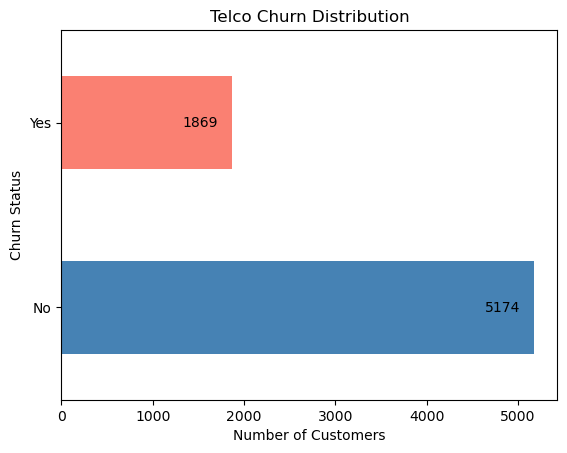

In [93]:
# Visualise churn distribution
ax= df['Churn'].value_counts().plot(kind='barh', color=['steelblue', 'salmon'])
plt.title('Telco Churn Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Churn Status')


for bar in ax.patches:
    ax.text(bar.get_width() - 150, 
            bar.get_y() + bar.get_height() / 2, 
            f'{int(bar.get_width())}', 
            va='center',
            ha='right',
            color='black')

plt.show()

## Churn by Contract Type

In [15]:
# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True)*100
print(contract_churn)

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64


### Churn Key notes
Customers with a month to month contract has the highest probability of churn(42.7%) which requires further investigation into the reasons for churn.
Customers with a one year contract has a significantly lower probability of churn with (11.2%) which shows that once the customer is locked in a contract, they are less likely to cancel their service.
Customers with a two year contract has the lowest probability to churn(2.8%).
This suggests that contract conversion (moving customers from month-to-month to longer-term agreements) could be one of the most effective levers for reducing churn.

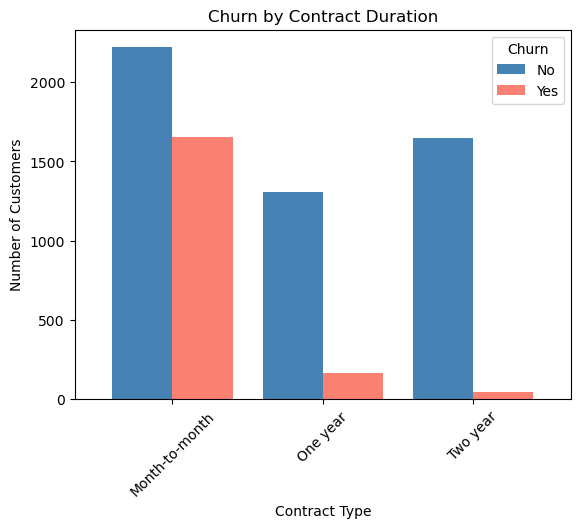

In [22]:
# Visualise churn rate by contract type

# Grouped bar chart - churn by contract type
contract_churn_grouped = df.groupby(['Contract', 'Churn']).size().unstack()

contract_churn_grouped.plot(kind='bar', 
                            color=['steelblue', 'salmon'],
                            width=0.8)
plt.title('Churn by Contract Duration')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.show()

## Churn by Tenure

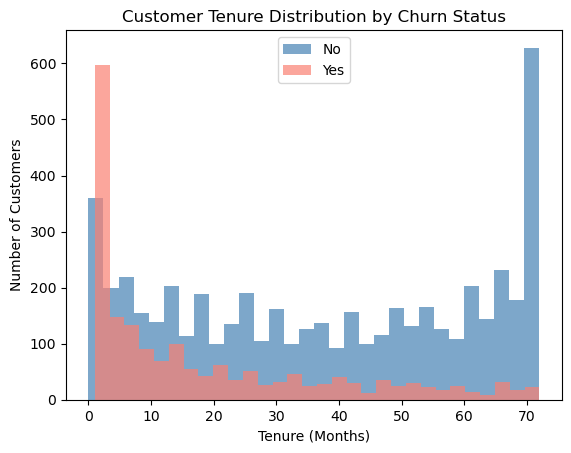

In [94]:
# Churn by tenure
df[df['Churn'] == 'No']['tenure'].plot(kind='hist', 
                                        bins=30, 
                                        alpha=0.7, 
                                        color='steelblue', 
                                        label='No')

df[df['Churn'] == 'Yes']['tenure'].plot(kind='hist', 
                                        bins=30, 
                                        alpha=0.7, 
                                        color='salmon', 
                                        label='Yes')

plt.title('Customer Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

### Key notes on Churn by Tenure
Churned customers are heavily concentrated in the early months of tenure, with the highest churn occurring within the first 10 months. Retained customers show a more even distribution across all tenure bands, with a notable spike at 70+ months indicating a loyal long-term customer base. This suggests that the first year of a customer relationship is the highest risk window and where retention interventions would have the greatest impact.

## Churn by Monthly Charges

In [95]:
# Average monthly charges by churn status
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()
print(avg_charges)

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


### Churn by Monthly Charges
Customers who churned had an average monthly charge of USD74.44, in comparison to USD61.27 for retained customers, a difference of USD13.17. This suggests that higher-paying customers are more likely to churn, possibly due to price sensitivity in a competitive market where alternative providers offer lower-cost options. Pricing strategy and perceived value may therefore be key drivers of churn worth investigating further.

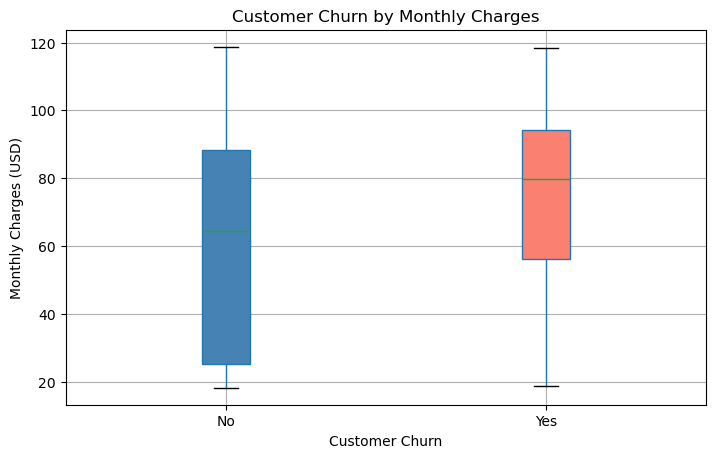

In [32]:
## Visualise Churn by Monthly Charges

# Boxplot - Monthly Charges by Churn Status

ax = df.boxplot(column='MonthlyCharges', 
           by='Churn', 
           figsize=(8,5),
           patch_artist=True)

colors = ['steelblue', 'salmon']
for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)

plt.title('Customer Churn by Monthly Charges')
plt.suptitle('')
plt.xlabel('Customer Churn')
plt.ylabel('Monthly Charges (USD)')
plt.show()

### Key observation - Churn by Monthly charges
Churned customers show a higher median monthly charge of USD 80 compared to USD 64 for retained customers. The interquartile range for retained customers is notably wider, indicating greater variability in pricing across that group. Churned customers are more tightly concentrated in the higher charge bands, suggesting that price sensitivity is a significant churn driver. Customers paying premium rates may not perceive sufficient value to justify the cost, making them more susceptible to competitor offers.

## Churn by Internet Service Type

In [39]:
churn_internetservice = df.groupby('InternetService')['Churn'].value_counts(normalize=True)*100
print(churn_internetservice)

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64


### Key Obersations - Churn by Internet Service Type
Customers with no internet service show the lowest churn rate at 7.4%, suggesting that simpler, lower-cost customers are far more loyal. Fiber optic customers churn at 41.8% — nearly six times the rate of non-internet customers — which points to a value perception gap rather than just price sensitivity alone. These customers are likely receiving a premium service but not feeling the value, making them highly susceptible to competitor offerings.

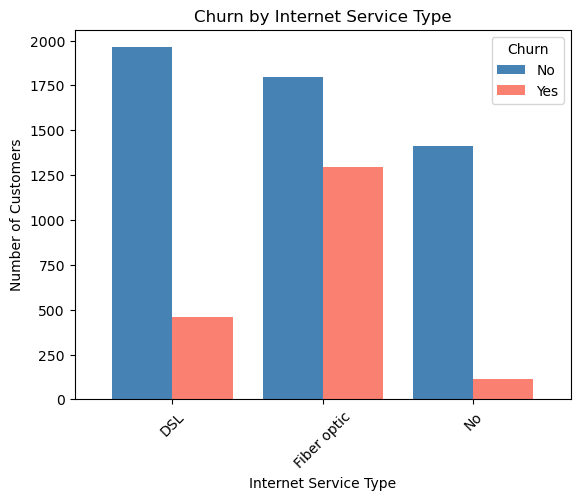

In [107]:
# Grouped bar chart - churn by internet service type
internetservice_churn_grouped = df.groupby(['InternetService', 'Churn']).size().unstack()

internetservice_churn_grouped.plot(kind='bar', 
                            color=['steelblue', 'salmon'],
                            width=0.8)
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.show()

## Churn by Payment Method

In [108]:
paymentmethod_churn_grouped = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)*100
print(paymentmethod_churn_grouped)

PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64


### Churn by Payment Method - Key Observations
Electronic check customers churn at 45.3% — nearly three times the rate of automatic payment customers. Automatic payment methods (bank transfer and credit card) show the lowest churn rates at 15-17%, suggesting that payment automation creates friction to cancel and may indicate a more committed customer relationship. Electronic check users may represent a less engaged, more price-sensitive segment who are actively managing their spend month to month.

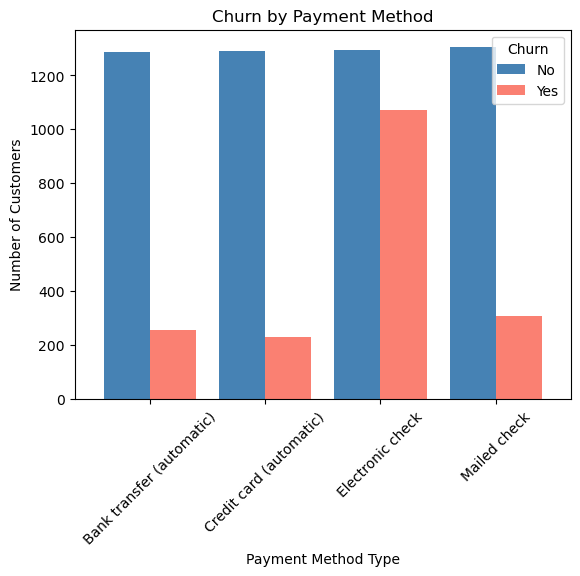

In [98]:
# Grouped bar chart - churn by payment method
internetservice_churn_grouped = df.groupby(['PaymentMethod', 'Churn']).size().unstack()

internetservice_churn_grouped.plot(kind='bar', 
                            color=['steelblue', 'salmon'],
                            width=0.8)
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.show()

## Churn by Senior Citizen Status

In [58]:
#Exploring data type
print(df['SeniorCitizen'].unique())

[0 1]


In [60]:
# Replace 0 and 1 with readable labels
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: 'No', 1: 'Yes'})

In [99]:
churn_by_seniorcitizen = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize = True) *100
print(churn_by_seniorcitizen)

SeniorCitizen  Churn
0              No       76.393832
               Yes      23.606168
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64


### Key Notes- Churn by Senior Citizen
Customers contracts who qualify as senior citizens experience a 41.6% chance of churn and appear to be more sensitive to price in coparison to Customers who are not senior citizens and churn of 23.6%. This customer catagory would benefit to pensioner discounts or targeted campaigns to retain this customer catagory.

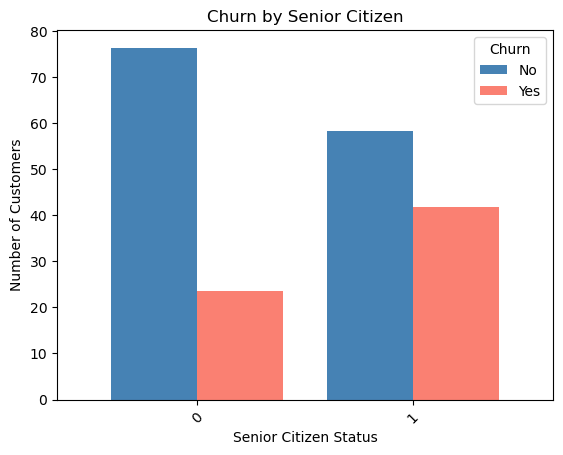

In [100]:
# Grouped bar chart - churn by Senior Citizenship Status
churn_by_seniorcitizen.unstack().plot(kind='bar', 
                            color=['steelblue', 'salmon'],
                            width=0.8)
plt.title('Churn by Senior Citizen')
plt.xlabel('Senior Citizen Status')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.show()

## Correlation Analysis

In [101]:
df1 = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [102]:
# Fix TotalCharges
df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'], errors='coerce')
df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

# Create numeric columns without overwriting originals
df1['Churn_numeric'] = df1['Churn'].map({'Yes': 1, 'No': 0})
df1['SeniorCitizen_numeric'] = df1['SeniorCitizen']  # already 0/1 in original

# Build heatmap dataframe
numeric_df = df1[['SeniorCitizen_numeric', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']]

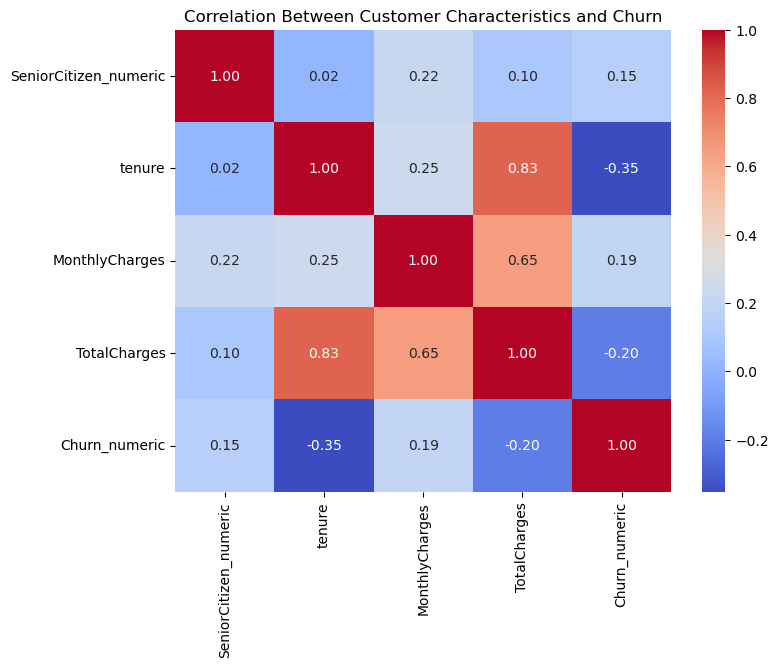

In [109]:
corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Between Customer Characteristics and Churn')
plt.show()

### Heatmap Key Observations
The strongest correlation with churn is tenure at -0.35, meaning that as tenure increases, churn decreases — longer-tenured customers are significantly less likely to leave. Monthly charges shows a positive correlation of 0.19, suggesting higher-paying customers are moderately more likely to churn. SeniorCitizen has the weakest correlation at 0.15, indicating that age alone is not a strong standalone predictor of churn. Tenure's negative correlation aligns with our earlier histogram finding that churn is heavily concentrated in the first 10 months of a customer relationship, confirming that the early tenure window is the highest risk period for customer loss.

## Summary & Key Findings

This analysis explored customer churn behaviour across a telco dataset of 7,043 customers, identifying key drivers and risk segments to inform retention strategy.

### Key Findings

**1. Overall Churn Rate**
The dataset revealed a churn rate of 26.5%, representing 1869 customers lost out of 7043 total. 
This is considered high for the telco industry and warrants targeted intervention.

**2. Contract Type is the Strongest Categorical Predictor**
Month-to-month customers churn at 42.7% compared to just 2.8% for two-year contract holders. 
Contract conversion is therefore one of the most effective levers available to reduce churn.

**3. Early Tenure is the Highest Risk Window**
Churn is heavily concentrated in the first 10 months of a customer relationship. 
Customers who survive beyond this window show significantly stronger retention rates.

**4. Higher Monthly Charges Drive Churn**
Churned customers pay an average of USD 71.44 per month versus USD 61.27 for retained customers. 
This suggests a value perception gap among higher-paying customers.

**5. Fiber Optic and Electronic Check Customers are High Risk Segments**
Fiber optic customers churn at 41.8% and electronic check users at 45.3% %. 
Both segments require targeted retention campaigns and pricing reviews.

### Recommendations

Based on the findings above, the following retention strategies are recommended:
1. **Prioritise contract conversion** - Incentivise month-to-month customers to upgrade to annual or two-year contracts through loyalty discounts or value-added benefits.
2. **Early tenure intervention** - Implement a structured onboarding and check-in programme for customers in their first 10 months to reduce early churn risk.
3. **Review Fiber Optic pricing and value proposition** — With a 41.8% churn rate, fiber optic customers are clearly not perceiving sufficient value. A pricing or service quality review is warranted.
4. **Target electronic check users** - This segment churns at 45.3%. Incentivising a switch to automatic payment methods could improve both retention and payment reliability.
5. **Senior citizen retention programme** - Although correlation is moderate, senior citizens churn at nearly double the rate of non-senior customers and would benefit from tailored pricing or support offerings.